# Quantium - Module 2

We will be examining the performance in trial vs control stores to provide a recommendation for each location based on our insight.

- Select control stores – explore the data and define metrics for control store selection – "What would make them a control store?" Visualize the drivers to see suitability.

- Assessment of the trial – get insights of each of the stores. Compare each trial store with ontrol store to get its overall performance. We want to know if the trial stores were successful or not. 

- Collate findings – summarise findings for each store and provide recommendations to share with client outlining the impact on sales during trial period.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
%matplotlib inline

DATA_DIR = Path(".")


In [2]:
qvi = pd.read_csv(DATA_DIR / "QVI_data.csv")
qvi.head()


,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [3]:
# Checking for nulls
qvi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


- Client has selected store numbers 77, 86 and 88 as trial stores.
- Client wants control stores to be established stores that are operational for the entire observation period.
- Trial period = 1 Feb 2019 to 30 April 2019.
- Compare trial stores to control stores that are similar pre-trial. Similarity measurement:
    - Monthly overall sales revenue
    - Monthly number of customers
    - Monthly number of transactions per customer


In [4]:
qvi["DATE"] = pd.to_datetime(qvi["DATE"])
qvi["YEARMONTH"] = qvi["DATE"].dt.strftime("%Y%m").astype("int")

Compile each store's monthly:
- Total sales
- Number of customers,
- Average transactions per customer
- Average chips per customer
- Average price per unit

In [5]:
def monthly_store_metrics():
    group = qvi.groupby(["STORE_NBR", "YEARMONTH"])
    total = group["TOT_SALES"].sum()
    customers = group["LYLTY_CARD_NBR"].nunique()
    # A transaction may have multiple product rows. Use the composite transaction key.
    transaction_key = ["STORE_NBR", "LYLTY_CARD_NBR", "DATE", "TXN_ID"]
    purchase_ids = pd.MultiIndex.from_frame(qvi[transaction_key]).factorize()[0]
    qvi_with_purchase = qvi.assign(purchase_id=purchase_ids)
    transactions = qvi_with_purchase.groupby(["STORE_NBR", "YEARMONTH"])["purchase_id"].nunique()
    units = group["PROD_QTY"].sum()
    metrics = pd.concat([total, customers, transactions / customers, units / transactions, total / units], axis=1)
    metrics.columns = ["TOT_SALES", "nCustomers", "nTxnPerCust", "nChipsPerTxn", "avgPricePerUnit"]
    return metrics


In [6]:
qvi_monthly_metrics = monthly_store_metrics().reset_index()
qvi_monthly_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3169 entries, 0 to 3168
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STORE_NBR        3169 non-null   int64  
 1   YEARMONTH        3169 non-null   int64  
 2   TOT_SALES        3169 non-null   float64
 3   nCustomers       3169 non-null   int64  
 4   nTxnPerCust      3169 non-null   float64
 5   nChipsPerTxn     3169 non-null   float64
 6   avgPricePerUnit  3169 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 173.4 KB


In [7]:
#pre trial observation
#filter only stores with full 12 months observation
observ_counts = qvi_monthly_metrics["STORE_NBR"].value_counts()
full_observ_index = observ_counts[observ_counts == 12].index
full_observ = qvi_monthly_metrics[qvi_monthly_metrics["STORE_NBR"].isin(full_observ_index)]
pretrial_full_observ = full_observ[full_observ["YEARMONTH"] < 201902]

pretrial_full_observ.head(8)

,STORE_NBR,YEARMONTH,TOT_SALES,nCustomers,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,49,1.061224,1.192308,3.337097
1,1,201808,176.1,42,1.023810,1.255814,3.261111
2,1,201809,278.8,59,1.050847,1.209677,3.717333
3,1,201810,188.1,44,1.022727,1.288889,3.243103
4,1,201811,192.6,46,1.021739,1.212766,3.378947
5,1,201812,189.6,42,1.119048,1.212766,3.326316
6,1,201901,154.8,35,1.028571,1.166667,3.685714
12,2,201807,150.8,39,1.051282,1.121951,3.278261


In [8]:
def calcCorrTable(metricCol, storeComparison, inputTable=pretrial_full_observ):
    """Correlate entire seven-month time series for trial and candidate stores."""
    candidates = inputTable.loc[~inputTable.STORE_NBR.isin([77, 86, 88]), "STORE_NBR"].unique()
    trial = inputTable.loc[inputTable.STORE_NBR.eq(storeComparison)].set_index("YEARMONTH").sort_index()
    rows = []
    for control in candidates:
        candidate = inputTable.loc[inputTable.STORE_NBR.eq(control)].set_index("YEARMONTH").sort_index()
        common = trial.index.intersection(candidate.index)
        if len(common) != 7:
            continue
        correlations = []
        for column in metricCol:
            trial_values = trial.loc[common, column]
            candidate_values = candidate.loc[common, column]
            if trial_values.std() == 0 or candidate_values.std() == 0:
                correlations.append(np.nan)
            else:
                correlations.append(trial_values.corr(candidate_values))
        score = float(np.nanmean(correlations))
        rows.append({"Trial_Str": storeComparison, "Ctrl_Str": control, "Corr_Score": score})
    return pd.DataFrame(rows)


In [9]:
corr_table = pd.concat([calcCorrTable(["TOT_SALES", "nCustomers", "nTxnPerCust", "nChipsPerTxn", "avgPricePerUnit"], trial_num)
                        for trial_num in [77, 86, 88]], ignore_index=True)
corr_table.head(8)


,Trial_Str,Ctrl_Str,Corr_Score
0,77,1,-0.272065
1,77,2,-0.159626
2,77,3,0.395487
3,77,4,-0.217309
4,77,5,0.235278
5,77,6,-0.104454
6,77,7,-0.067716
7,77,8,-0.118998


In [10]:
def calculateMagnitudeDistance(metricCol, storeComparison, inputTable=pretrial_full_observ):
    """Compare monthly levels by matching the same month in both stores."""
    trial = inputTable.loc[inputTable.STORE_NBR.eq(storeComparison)].set_index("YEARMONTH").sort_index()
    candidates = inputTable.loc[~inputTable.STORE_NBR.isin([77, 86, 88]), "STORE_NBR"].unique()
    rows = []
    for control in candidates:
        candidate = inputTable.loc[inputTable.STORE_NBR.eq(control)].set_index("YEARMONTH").sort_index()
        common = trial.index.intersection(candidate.index)
        if len(common) != 7:
            continue
        distance = (trial.loc[common, metricCol] - candidate.loc[common, metricCol]).abs()
        # Scale by the trial's pre-trial mean; the score does not depend on other candidates.
        similarity = np.exp(-distance.div(trial[metricCol].mean()).mean()).mean()
        rows.append({"Trial_Str": storeComparison, "Ctrl_Str": control, "magnitude": float(similarity)})
    return pd.DataFrame(rows)


In [11]:
dist_table = pd.concat([calculateMagnitudeDistance(["TOT_SALES", "nCustomers", "nTxnPerCust", "nChipsPerTxn", "avgPricePerUnit"], trial_num)
                        for trial_num in [77, 86, 88]], ignore_index=True)
dist_table.head(8)


,Trial_Str,Ctrl_Str,magnitude
0,77,1,0.866670
1,77,2,0.844255
2,77,3,0.538087
3,77,4,0.508810
4,77,5,0.582153
5,77,6,0.903876
6,77,7,0.543417
7,77,8,0.783402


We'll select control stores based on how similar monthly total sales in dollar amounts and monthly number of customers are to the trial stores by using correlation and magnitude distance.

In [12]:
def combine_corr_dist(metricCol, storeComparison, inputTable=pretrial_full_observ):
    correlations = calcCorrTable(metricCol, storeComparison, inputTable)
    distances = calculateMagnitudeDistance(metricCol, storeComparison, inputTable)
    return correlations.merge(distances, on=["Trial_Str", "Ctrl_Str"], validate="one_to_one")


In [13]:
compare_metrics_table1 = pd.DataFrame()
for trial_num in [77, 86, 88]:
    compare_metrics_table1 = pd.concat([compare_metrics_table1, combine_corr_dist(["TOT_SALES"], trial_num)])

In [14]:
corr_weight = 0.5
dist_weight = 0.5
# Correlation ranges from -1 to 1; convert it to a 0-to-1 similarity before averaging.


In [15]:
grouped_comparison_table1 = compare_metrics_table1.copy()
grouped_comparison_table1["CompScore"] = corr_weight * ((grouped_comparison_table1.Corr_Score + 1) / 2) + dist_weight * grouped_comparison_table1.magnitude
for trial_num in [77, 86, 88]:
    print(grouped_comparison_table1[grouped_comparison_table1.Trial_Str.eq(trial_num)].nlargest(5, "CompScore").to_string(index=False), "\n")


 Trial_Str  Ctrl_Str  Corr_Score  magnitude  CompScore
        77       233    0.903774   0.925358   0.938622
        77        50    0.763866   0.866732   0.874333
        77        41    0.783232   0.829597   0.860606
        77        53    0.532764   0.874778   0.820580
        77       265    0.639759   0.819647   0.819763 

 Trial_Str  Ctrl_Str  Corr_Score  magnitude  CompScore
        86       155    0.877882   0.963548   0.951244
        86       109    0.788300   0.964493   0.929321
        86       222    0.795075   0.959808   0.928673
        86       138    0.759864   0.927886   0.903909
        86       114    0.734415   0.924367   0.895788 

 Trial_Str  Ctrl_Str  Corr_Score  magnitude  CompScore
        88       203    0.508001   0.951887   0.852944
        88       125    0.624109   0.863620   0.837837
        88       201    0.492735   0.881064   0.813716
        88         7    0.649657   0.802031   0.813430
        88       237    0.308479   0.957350   0.805795 



In [16]:
compare_metrics_table2 = pd.DataFrame()
for trial_num in [77, 86, 88]:
    compare_metrics_table2 = pd.concat([compare_metrics_table2, combine_corr_dist(["nCustomers"], trial_num)])

In [17]:
grouped_comparison_table2 = compare_metrics_table2.copy()
grouped_comparison_table2["CompScore"] = corr_weight * ((grouped_comparison_table2.Corr_Score + 1) / 2) + dist_weight * grouped_comparison_table2.magnitude
for trial_num in [77, 86, 88]:
    print(grouped_comparison_table2[grouped_comparison_table2.Trial_Str.eq(trial_num)].nlargest(5, "CompScore").to_string(index=False), "\n")


 Trial_Str  Ctrl_Str  Corr_Score  magnitude  CompScore
        77       233    0.990358   0.983417   0.989298
        77        41    0.844219   0.944730   0.933420
        77       254    0.916208   0.866050   0.912077
        77        17    0.747308   0.919788   0.896721
        77       115    0.718882   0.922869   0.891155 

 Trial_Str  Ctrl_Str  Corr_Score  magnitude  CompScore
        86       155    0.942876   0.985755   0.978597
        86       114    0.855339   0.938824   0.933247
        86       109    0.770778   0.967540   0.926464
        86       225    0.733791   0.967540   0.917218
        86       138    0.749701   0.932113   0.903482 

 Trial_Str  Ctrl_Str  Corr_Score  magnitude  CompScore
        88       237    0.947326   0.987578   0.980620
        88       178    0.939466   0.838504   0.904118
        88        69    0.815792   0.879494   0.893695
        88       113    0.862632   0.808560   0.869938
        88       123    0.627925   0.901758   0.857860 



In [18]:
combined_scores = grouped_comparison_table1[["Trial_Str", "Ctrl_Str", "CompScore"]].merge(
    grouped_comparison_table2[["Trial_Str", "Ctrl_Str", "CompScore"]],
    on=["Trial_Str", "Ctrl_Str"], suffixes=("_sales", "_customers"), validate="one_to_one")
combined_scores["overall_score"] = (combined_scores.CompScore_sales + combined_scores.CompScore_customers) / 2
combined_scores = combined_scores.sort_values(["Trial_Str", "overall_score"], ascending=[True, False])
for trial_num in [77, 86, 88]:
    print(combined_scores[combined_scores.Trial_Str.eq(trial_num)].head(3).to_string(index=False), "\n")


 Trial_Str  Ctrl_Str  CompScore_sales  CompScore_customers  overall_score
        77       233         0.938622             0.989298       0.963960
        77        41         0.860606             0.933420       0.897013
        77        50         0.874333             0.822033       0.848183 

 Trial_Str  Ctrl_Str  CompScore_sales  CompScore_customers  overall_score
        86       155         0.951244             0.978597       0.964920
        86       109         0.929321             0.926464       0.927893
        86       114         0.895788             0.933247       0.914517 

 Trial_Str  Ctrl_Str  CompScore_sales  CompScore_customers  overall_score
        88       237         0.805795             0.980620       0.893208
        88       178         0.802426             0.904118       0.853272
        88       201         0.813716             0.840119       0.826917 



Control candidates are ranked using seven-month sales and customer correlations together with month-matched size similarity. The tables above show sales, customer and combined scores.


Based on the combined sales and customer scores, the selected controls are 77→233, 86→155 and 88→237. Store 88's sales-series fit is weaker than the other two pairings, so its result needs a control-choice sensitivity check.


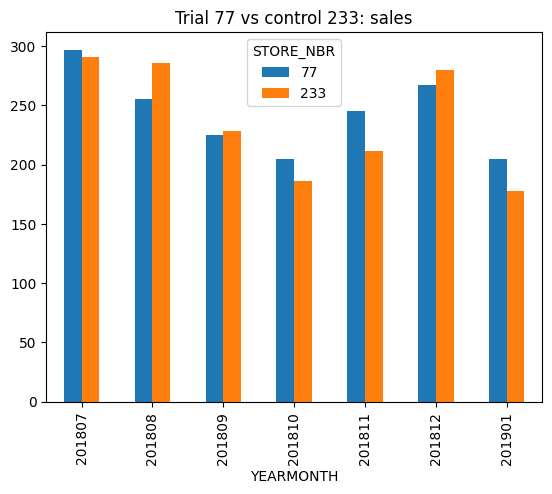

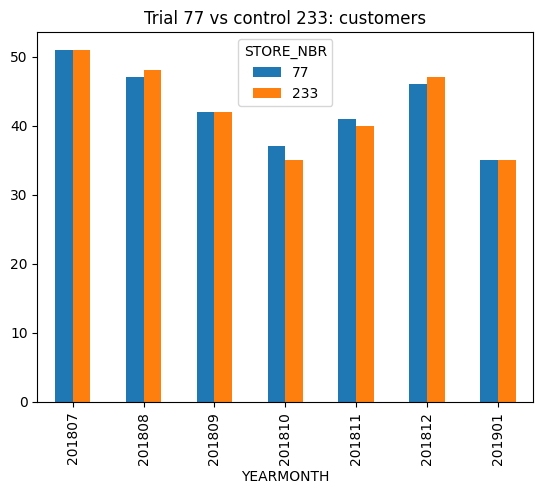

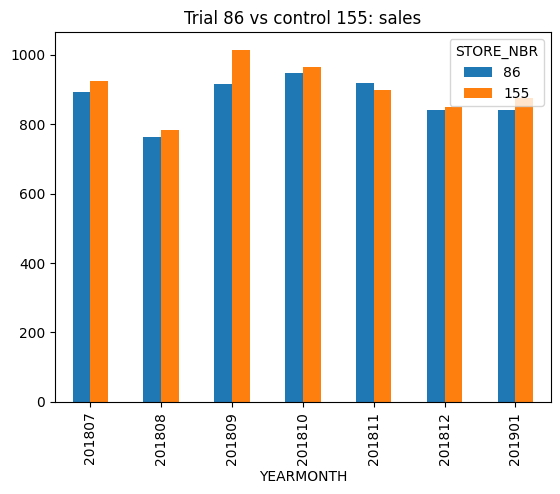

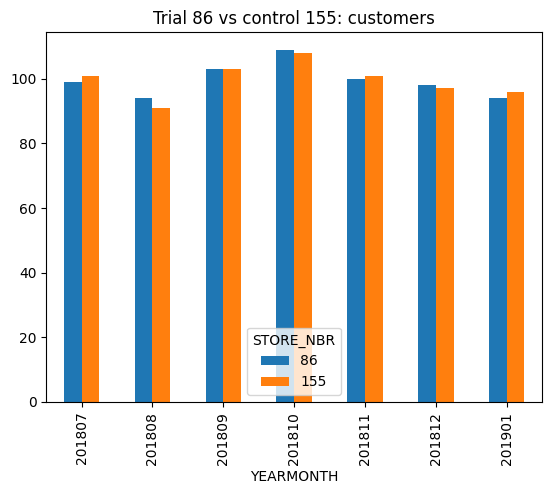

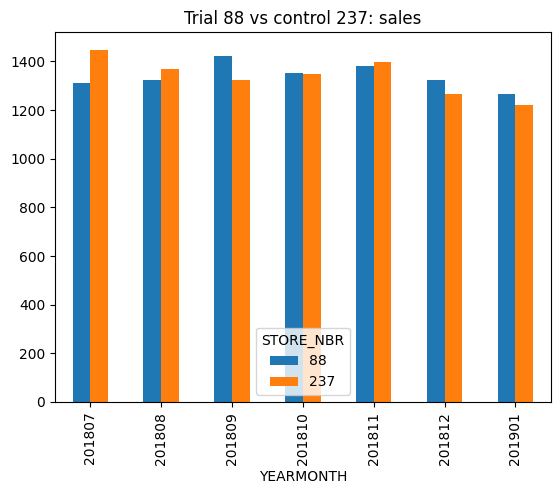

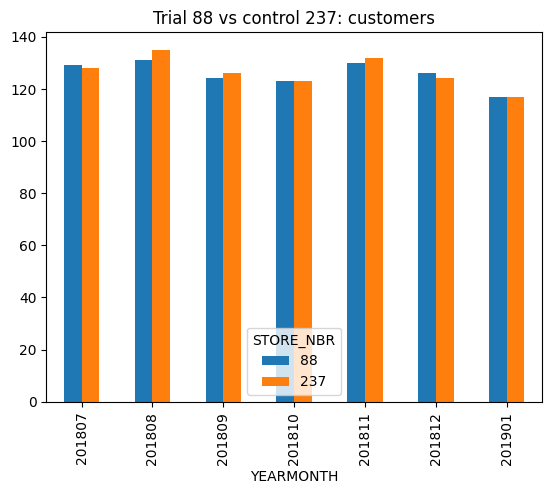

In [19]:
trial_control_dic = {int(row.Trial_Str): int(row.Ctrl_Str)
                     for row in combined_scores.drop_duplicates("Trial_Str").itertuples()}
for trial, control in trial_control_dic.items():
    pretrial_full_observ[pretrial_full_observ.STORE_NBR.isin([trial, control])].pivot(
        index="YEARMONTH", columns="STORE_NBR", values="TOT_SALES").plot.bar(title=f"Trial {trial} vs control {control}: sales")
    plt.show()
    pretrial_full_observ[pretrial_full_observ.STORE_NBR.isin([trial, control])].pivot(
        index="YEARMONTH", columns="STORE_NBR", values="nCustomers").plot.bar(title=f"Trial {trial} vs control {control}: customers")
    plt.show()


Next we'll compare the performance of Trial stores to Control stores during the trial period. To ensure their performance is comparable during Trial period, we need to scale (multiply to ratio of trial / control) all of Control stores' performance to Trial store's performance during pre-trial. Starting with TOT_SALES.

In [20]:
sales_ratios = {
    trial: pretrial_full_observ.loc[pretrial_full_observ.STORE_NBR.eq(trial), "TOT_SALES"].sum()
           / pretrial_full_observ.loc[pretrial_full_observ.STORE_NBR.eq(control), "TOT_SALES"].sum()
    for trial, control in trial_control_dic.items()
}
sales_ratios


{77: 1.023617303289553, 86: 0.9700651481287743, 88: 1.001558330664959}

In [21]:
trial_full_observ = full_observ[full_observ.YEARMONTH.between(201902, 201904)].copy()
scaled_sales_control_stores = full_observ[full_observ.STORE_NBR.isin(trial_control_dic.values())][
    ["STORE_NBR", "YEARMONTH", "TOT_SALES"]].copy()
control_to_trial = {control: trial for trial, control in trial_control_dic.items()}
scaled_sales_control_stores["ScaledSales"] = scaled_sales_control_stores.apply(
    lambda row: row.TOT_SALES * sales_ratios[control_to_trial[row.STORE_NBR]], axis=1)
trial_scaled_sales_control_stores = scaled_sales_control_stores[scaled_sales_control_stores.YEARMONTH.between(201902, 201904)]
pretrial_scaled_sales_control_stores = scaled_sales_control_stores[scaled_sales_control_stores.YEARMONTH.lt(201902)]


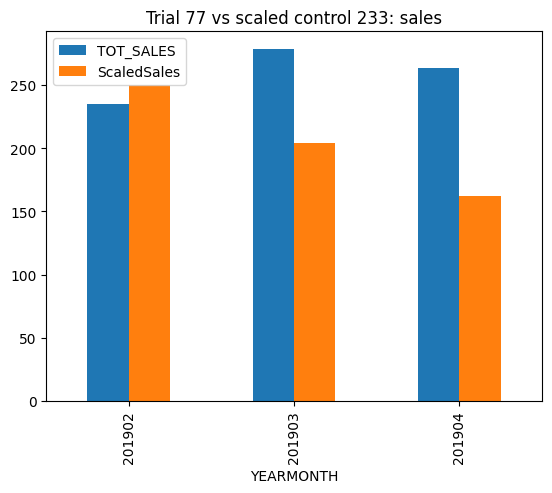

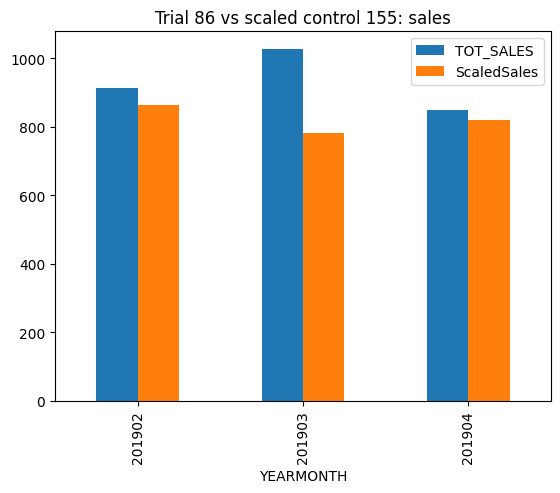

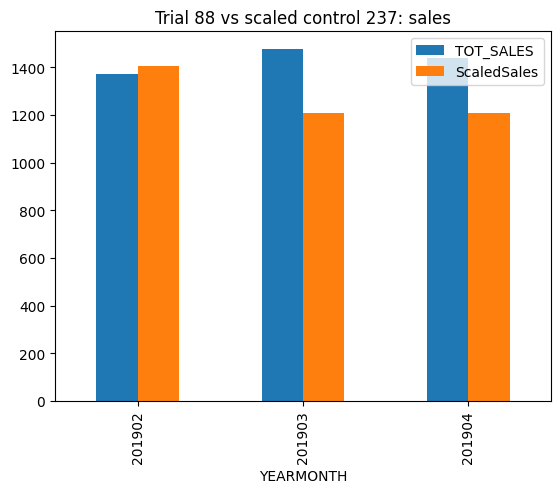

In [22]:
percentage_diff = {}
for trial, control in trial_control_dic.items():
    a = trial_scaled_sales_control_stores[trial_scaled_sales_control_stores.STORE_NBR.eq(control)]
    b = trial_full_observ[trial_full_observ.STORE_NBR.eq(trial)]
    percentage_diff[trial] = b.TOT_SALES.sum() / a.ScaledSales.sum()
    b[["YEARMONTH", "TOT_SALES"]].merge(a[["YEARMONTH", "ScaledSales"]], on="YEARMONTH", validate="one_to_one").set_index("YEARMONTH").plot.bar(title=f"Trial {trial} vs scaled control {control}: sales")
    plt.show()


In [23]:
percentage_diff

{77: 1.2615468650086281, 86: 1.1315014357363697, 88: 1.121157308767232}

In [24]:
sales_pairs = []
for trial, control in trial_control_dic.items():
    actual = full_observ[full_observ.STORE_NBR.eq(trial)][["YEARMONTH", "TOT_SALES"]]
    benchmark = scaled_sales_control_stores[scaled_sales_control_stores.STORE_NBR.eq(control)][["YEARMONTH", "ScaledSales"]]
    pair = actual.merge(benchmark, on="YEARMONTH", validate="one_to_one")
    pair["t_STORE_NBR"], pair["c_STORE_NBR"] = trial, control
    pair["Sales_Percentage_Diff"] = pair.TOT_SALES / pair.ScaledSales - 1
    pair["trial_period"] = np.select([pair.YEARMONTH.lt(201902), pair.YEARMONTH.le(201904)], ["pre", "trial"], default="post")
    sales_pairs.append(pair)
scaledsales_vs_trial = pd.concat(sales_pairs, ignore_index=True)
scaledsales_vs_trial[scaledsales_vs_trial.trial_period.eq("trial")]


,YEARMONTH,TOT_SALES,ScaledSales,t_STORE_NBR,c_STORE_NBR,Sales_Percentage_Diff,trial_period
7,201902,235.0,249.762622,77,233,-0.059107,trial
8,201903,278.5,203.802205,77,233,0.366521,trial
9,201904,263.5,162.345704,77,233,0.623080,trial
19,201902,913.2,864.522060,86,155,0.056306,trial
20,201903,1026.8,780.320405,86,155,0.315870,trial
21,201904,848.2,819.317024,86,155,0.035253,trial
31,201902,1370.2,1406.989143,88,237,-0.026147,trial
32,201903,1477.2,1210.082775,88,237,0.220743,trial
33,201904,1439.4,1206.477165,88,237,0.193060,trial


### Sales inference

Compare the trial-minus-scaled-control monthly percentage gap before and during the trial (a paired difference-in-differences view). Because there are only seven pre-trial and three trial months, report an exact two-sided month-label permutation p-value and a bootstrap interval. Apply Holm adjustment across the six store-by-metric tests. These are exploratory time-series checks, not proof of a randomized causal effect.


In [25]:
def evaluate_gap(pairs, metric, benchmark):
    rows = []
    rng = np.random.default_rng(20261009)
    for trial, control in trial_control_dic.items():
        pair = pairs[pairs.t_STORE_NBR.eq(trial) & pairs.YEARMONTH.le(201904)].sort_values("YEARMONTH")
        gaps = pair[metric].to_numpy() / pair[benchmark].to_numpy() - 1
        pre, during = gaps[:7], gaps[7:]
        observed = float(during.mean() - pre.mean())
        # All C(10,3)=120 possible placements of three trial months.
        permuted = []
        for chosen in itertools.combinations(range(10), 3):
            selected = np.zeros(10, dtype=bool)
            selected[list(chosen)] = True
            permuted.append(gaps[selected].mean() - gaps[~selected].mean())
        pvalue = np.mean(np.abs(permuted) >= abs(observed) - 1e-12)
        boot = rng.choice(during, (20000, 3), replace=True).mean(axis=1) - rng.choice(pre, (20000, 7), replace=True).mean(axis=1)
        low, high = np.quantile(boot, [0.025, 0.975])
        rows.append({"trial_store": trial, "control_store": control,
                     "trial_total_uplift_pct": 100 * (pair[metric].iloc[7:].sum() / pair[benchmark].iloc[7:].sum() - 1),
                     "mean_gap_change_pp": 100 * observed,
                     "bootstrap_low_pp": 100 * low, "bootstrap_high_pp": 100 * high,
                     "permutation_p": pvalue})
    return pd.DataFrame(rows)

sales_results = evaluate_gap(scaledsales_vs_trial, "TOT_SALES", "ScaledSales")
sales_results.round(4)


,trial_store,control_store,trial_total_uplift_pct,mean_gap_change_pp,bootstrap_low_pp,bootstrap_high_pp,permutation_p
0,77,233,26.1547,29.5953,-6.0217,59.9198,0.0500
1,86,155,13.1501,13.4397,2.5047,30.8958,0.0167
2,88,237,12.1157,12.6946,-2.2384,23.5259,0.0583


In [26]:
# Inspect pre-trial fit rather than testing a difference forced to zero by scaling.
sales_pre_fit = grouped_comparison_table1[grouped_comparison_table1.apply(
    lambda row: trial_control_dic[int(row.Trial_Str)] == int(row.Ctrl_Str), axis=1)][
    ["Trial_Str", "Ctrl_Str", "Corr_Score", "magnitude", "CompScore"]]
sales_pre_fit.round(3)


,Trial_Str,Ctrl_Str,Corr_Score,magnitude,CompScore
218,77,233,0.904,0.925,0.939
144,86,155,0.878,0.964,0.951
222,88,237,0.308,0.957,0.806


The pre-trial scale ratio forces the two stores' seven-month totals to match. It does not establish that their monthly trends match; the correlation and monthly gaps above are the relevant fit checks.


In [27]:
sales_results[["trial_store", "control_store", "trial_total_uplift_pct", "mean_gap_change_pp", "permutation_p"]].round(4)


,trial_store,control_store,trial_total_uplift_pct,mean_gap_change_pp,permutation_p
0,77,233,26.1547,29.5953,0.0500
1,86,155,13.1501,13.4397,0.0167
2,88,237,12.1157,12.6946,0.0583


The table reports a three-month aggregate uplift and the change in average monthly trial-control gap. Bootstrap intervals and exact permutation p-values quantify uncertainty; the final six-test adjustment appears after the customer analysis.


In [28]:
scaledsales_vs_trial[scaledsales_vs_trial.trial_period.eq("trial")][
    ["t_STORE_NBR", "c_STORE_NBR", "YEARMONTH", "TOT_SALES", "ScaledSales", "Sales_Percentage_Diff"]].round(3)


,t_STORE_NBR,c_STORE_NBR,YEARMONTH,TOT_SALES,ScaledSales,Sales_Percentage_Diff
7,77,233,201902,235.0,249.763,-0.059
8,77,233,201903,278.5,203.802,0.367
9,77,233,201904,263.5,162.346,0.623
19,86,155,201902,913.2,864.522,0.056
20,86,155,201903,1026.8,780.320,0.316
21,86,155,201904,848.2,819.317,0.035
31,88,237,201902,1370.2,1406.989,-0.026
32,88,237,201903,1477.2,1210.083,0.221
33,88,237,201904,1439.4,1206.477,0.193


All three trial stores show a positive three-month aggregate sales difference versus their selected scaled controls. Monthly gaps vary, so interpretation uses the exact permutation p-values and six-test-adjusted results.


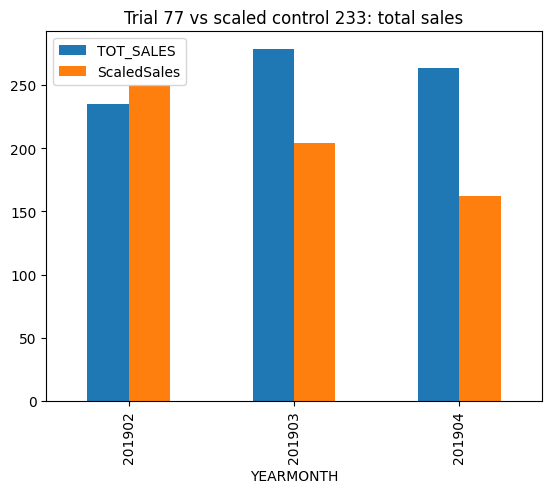

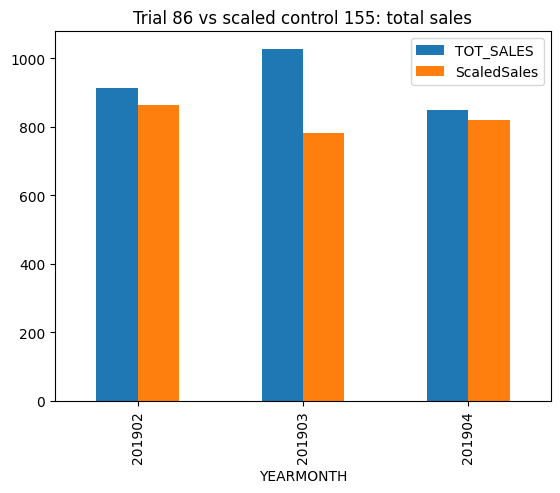

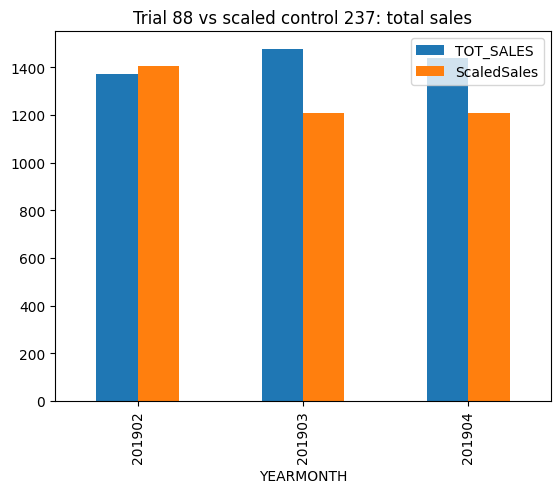

In [29]:
for trial, control in trial_control_dic.items():
    pair = scaledsales_vs_trial[(scaledsales_vs_trial.t_STORE_NBR.eq(trial)) & (scaledsales_vs_trial.trial_period.eq("trial"))]
    pair.set_index("YEARMONTH")[["TOT_SALES", "ScaledSales"]].plot.bar(title=f"Trial {trial} vs scaled control {control}: total sales")
    plt.show()


The bar charts compare the actual sales with the correctly scaled control for each trial month. Next, apply the same method to unique monthly customer counts.


In [30]:
ncust_ratios = {
    trial: pretrial_full_observ.loc[pretrial_full_observ.STORE_NBR.eq(trial), "nCustomers"].sum()
           / pretrial_full_observ.loc[pretrial_full_observ.STORE_NBR.eq(control), "nCustomers"].sum()
    for trial, control in trial_control_dic.items()
}
ncust_ratios


{77: 1.0033557046979866, 86: 1.0, 88: 0.9943502824858758}

In [31]:
scaled_ncust_control_stores = full_observ[full_observ.STORE_NBR.isin(trial_control_dic.values())][
    ["STORE_NBR", "YEARMONTH", "nCustomers"]].copy()
scaled_ncust_control_stores["ScaledNcust"] = scaled_ncust_control_stores.apply(
    lambda row: row.nCustomers * ncust_ratios[control_to_trial[row.STORE_NBR]], axis=1)
trial_scaled_ncust_control_stores = scaled_ncust_control_stores[scaled_ncust_control_stores.YEARMONTH.between(201902, 201904)]
pretrial_scaled_ncust_control_stores = scaled_ncust_control_stores[scaled_ncust_control_stores.YEARMONTH.lt(201902)]


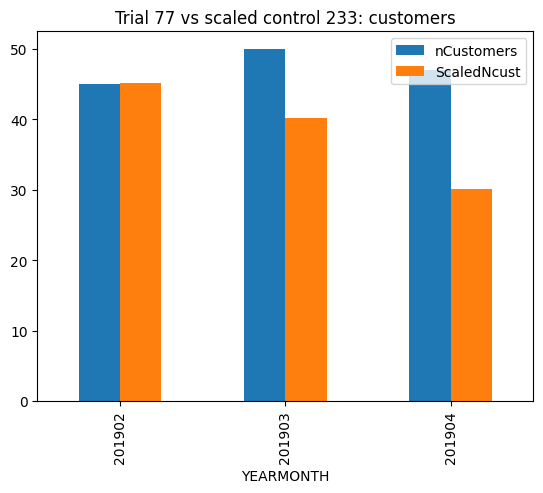

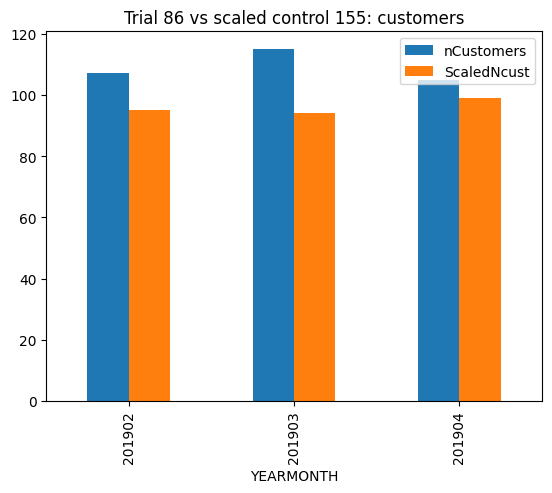

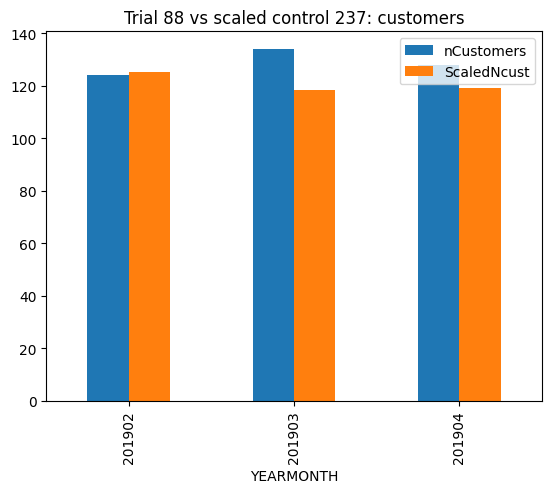

In [32]:
ncust_percentage_diff = {}
for trial, control in trial_control_dic.items():
    a = trial_scaled_ncust_control_stores[trial_scaled_ncust_control_stores.STORE_NBR.eq(control)]
    b = trial_full_observ[trial_full_observ.STORE_NBR.eq(trial)]
    ncust_percentage_diff[trial] = b.nCustomers.sum() / a.ScaledNcust.sum()
    b[["YEARMONTH", "nCustomers"]].merge(a[["YEARMONTH", "ScaledNcust"]], on="YEARMONTH", validate="one_to_one").set_index("YEARMONTH").plot.bar(title=f"Trial {trial} vs scaled control {control}: customers")
    plt.show()


In [33]:
ncust_percentage_diff

{77: 1.2306529009742622, 86: 1.1354166666666667, 88: 1.0635429638854295}

In [34]:
customer_pairs = []
for trial, control in trial_control_dic.items():
    actual = full_observ[full_observ.STORE_NBR.eq(trial)][["YEARMONTH", "nCustomers"]]
    benchmark = scaled_ncust_control_stores[scaled_ncust_control_stores.STORE_NBR.eq(control)][["YEARMONTH", "ScaledNcust"]]
    pair = actual.merge(benchmark, on="YEARMONTH", validate="one_to_one")
    pair["t_STORE_NBR"], pair["c_STORE_NBR"] = trial, control
    pair["nCust_Percentage_Diff"] = pair.nCustomers / pair.ScaledNcust - 1
    pair["trial_period"] = np.select([pair.YEARMONTH.lt(201902), pair.YEARMONTH.le(201904)], ["pre", "trial"], default="post")
    customer_pairs.append(pair)
scaledncust_vs_trial = pd.concat(customer_pairs, ignore_index=True)
scaledncust_vs_trial[scaledncust_vs_trial.trial_period.eq("trial")]


,YEARMONTH,nCustomers,ScaledNcust,t_STORE_NBR,c_STORE_NBR,nCust_Percentage_Diff,trial_period
7,201902,45,45.151007,77,233,-0.003344,trial
8,201903,50,40.134228,77,233,0.245819,trial
9,201904,47,30.100671,77,233,0.561427,trial
19,201902,107,95.000000,86,155,0.126316,trial
20,201903,115,94.000000,86,155,0.223404,trial
21,201904,105,99.000000,86,155,0.060606,trial
31,201902,124,125.288136,88,237,-0.010281,trial
32,201903,134,118.327684,88,237,0.132448,trial
33,201904,128,119.322034,88,237,0.072727,trial


### Customer-count inference

Use the same pre-trial scaling, paired month gaps, exact permutation test and bootstrap interval as for sales. The customer metric counts distinct loyalty cards per store and month.


In [35]:
customer_results = evaluate_gap(scaledncust_vs_trial, "nCustomers", "ScaledNcust")
customer_results.round(4)


,trial_store,control_store,trial_total_uplift_pct,mean_gap_change_pp,bootstrap_low_pp,bootstrap_high_pp,permutation_p
0,77,233,23.0653,26.5612,-0.1186,55.6042,0.0500
1,86,155,13.5417,13.6490,6.3296,22.1496,0.0083
2,88,237,6.3543,6.4557,-0.8609,12.9828,0.0583


In [36]:
def holm_adjust(pvalues):
    ordered = pvalues.sort_values()
    result = pd.Series(index=pvalues.index, dtype=float)
    running = 0.0
    for i, (index, pvalue) in enumerate(ordered.items()):
        running = max(running, min(1.0, (len(ordered) - i) * pvalue))
        result.loc[index] = running
    return result

all_results = pd.concat([sales_results.assign(metric="sales"), customer_results.assign(metric="customers")], ignore_index=True)
all_results["holm_p_six_tests"] = holm_adjust(all_results.permutation_p)
all_results.round(4)


,trial_store,control_store,trial_total_uplift_pct,mean_gap_change_pp,bootstrap_low_pp,bootstrap_high_pp,permutation_p,metric,holm_p_six_tests
0,77,233,26.1547,29.5953,-6.0217,59.9198,0.0500,sales,0.2000
1,86,155,13.1501,13.4397,2.5047,30.8958,0.0167,sales,0.0833
2,88,237,12.1157,12.6946,-2.2384,23.5259,0.0583,sales,0.2000
3,77,233,23.0653,26.5612,-0.1186,55.6042,0.0500,customers,0.2000
4,86,155,13.5417,13.6490,6.3296,22.1496,0.0083,customers,0.0500
5,88,237,6.3543,6.4557,-0.8609,12.9828,0.0583,customers,0.2000


In [37]:
scaledncust_vs_trial[scaledncust_vs_trial.trial_period.eq("trial")][
    ["t_STORE_NBR", "c_STORE_NBR", "YEARMONTH", "nCustomers", "ScaledNcust", "nCust_Percentage_Diff"]].round(3)


,t_STORE_NBR,c_STORE_NBR,YEARMONTH,nCustomers,ScaledNcust,nCust_Percentage_Diff
7,77,233,201902,45,45.151,-0.003
8,77,233,201903,50,40.134,0.246
9,77,233,201904,47,30.101,0.561
19,86,155,201902,107,95.000,0.126
20,86,155,201903,115,94.000,0.223
21,86,155,201904,105,99.000,0.061
31,88,237,201902,124,125.288,-0.010
32,88,237,201903,134,118.328,0.132
33,88,237,201904,128,119.322,0.073


Customer counts exceed the scaled control for all three trial stores over the three-month period. After adjusting the six sales/customer tests, only the 86/customer comparison is approximately at the 0.05 threshold. Individual-month differences are descriptive.


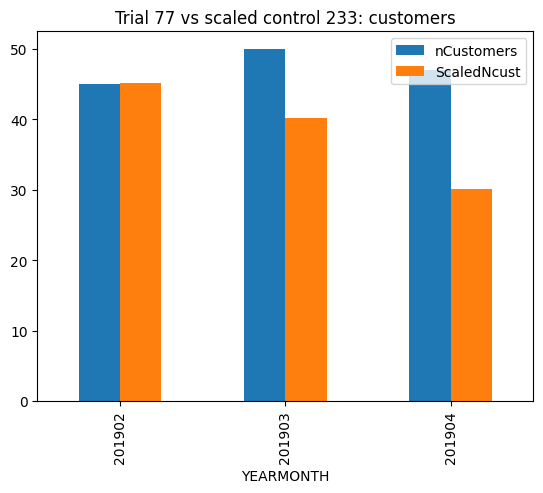

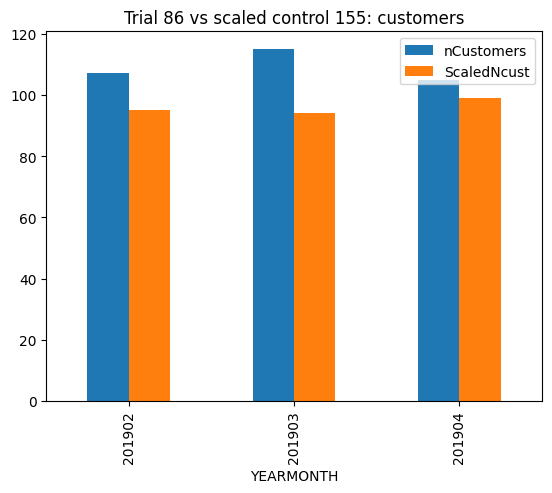

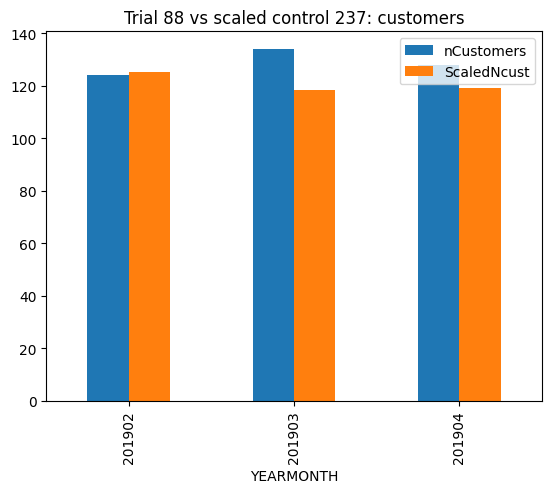

In [38]:
for trial, control in trial_control_dic.items():
    pair = scaledncust_vs_trial[(scaledncust_vs_trial.t_STORE_NBR.eq(trial)) & (scaledncust_vs_trial.trial_period.eq("trial"))]
    pair.set_index("YEARMONTH")[["nCustomers", "ScaledNcust"]].plot.bar(title=f"Trial {trial} vs scaled control {control}: customers")
    plt.show()


The charts show customer count versus its scaled control for each trial month. The uncertainty table above gives the three-month assessment.


- Seven-month sales and customer similarity selects controls 77→233, 86→155 and 88→237.
- Both sales and customer counts show positive three-month aggregate gaps for 77 and 86. After six-test adjustment, only the 86/customer result reaches approximately p = 0.05.
- Store 88's estimated effect is sensitive to its control choice; the 237 pairing has weaker sales correlation than the other selected pairs. This dataset cannot determine whether store-layout execution, local demand, promotions or inventory caused the variation.
- With only seven pre-trial and three trial months, the bootstrap interval and exact month-label permutation are exploratory. They do not by themselves establish a causal uplift.


In [39]:
# Sensitivity of store 88 to the choice of control, followed by a descriptive driver check.
alternatives = list(dict.fromkeys(combined_scores[combined_scores.Trial_Str.eq(88)].head(5).Ctrl_Str.astype(int).tolist() + [40]))
sensitivity_rows = []
for control in alternatives:
    pre_trial = pretrial_full_observ[pretrial_full_observ.STORE_NBR.eq(88)]
    pre_control = pretrial_full_observ[pretrial_full_observ.STORE_NBR.eq(control)]
    during_trial = trial_full_observ[trial_full_observ.STORE_NBR.eq(88)]
    during_control = trial_full_observ[trial_full_observ.STORE_NBR.eq(control)]
    row = {"control_store": control}
    for metric in ["TOT_SALES", "nCustomers"]:
        scale = pre_trial[metric].sum() / pre_control[metric].sum()
        row[f"{metric}_uplift_pct"] = 100 * (during_trial[metric].sum() / (during_control[metric].sum() * scale) - 1)
    sensitivity_rows.append(row)
store88_sensitivity = pd.DataFrame(sensitivity_rows)
print("Store 88 control sensitivity:\n", store88_sensitivity.round(2).to_string(index=False))

factor_rows = []
for store in [88, trial_control_dic[88]]:
    pre = full_observ[full_observ.STORE_NBR.eq(store) & full_observ.YEARMONTH.lt(201902)]
    during = full_observ[full_observ.STORE_NBR.eq(store) & full_observ.YEARMONTH.between(201902, 201904)]
    for metric in ["TOT_SALES", "nCustomers", "nTxnPerCust", "nChipsPerTxn", "avgPricePerUnit"]:
        factor_rows.append({"store": store, "metric": metric,
                            "pre_mean": pre[metric].mean(), "trial_mean": during[metric].mean(),
                            "change_pct": 100 * (during[metric].mean() / pre[metric].mean() - 1)})
store88_drivers = pd.DataFrame(factor_rows)
store88_drivers.round(3)


Store 88 control sensitivity:
  control_store  TOT_SALES_uplift_pct  nCustomers_uplift_pct
           237                 12.12                   6.35
           178                 -5.01                  -5.91
           201                 -0.16                  -2.00
           203                 24.93                  13.64
           123                  6.87                   2.56
            40                  4.35                   4.45


,store,metric,pre_mean,trial_mean,change_pct
0,88,TOT_SALES,1340.514,1428.933,6.596
1,88,nCustomers,125.714,128.667,2.348
2,88,nTxnPerCust,1.218,1.254,2.946
3,88,nChipsPerTxn,2.005,2.008,0.157
4,88,avgPricePerUnit,4.370,4.412,0.953
5,237,TOT_SALES,1338.429,1272.533,-4.923
6,237,nCustomers,126.429,121.667,-3.766
7,237,nTxnPerCust,1.205,1.166,-3.257
8,237,nChipsPerTxn,1.989,2.020,1.537
9,237,avgPricePerUnit,4.417,4.437,0.458
